In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap

In [59]:
df = pd.read_csv("C:/Games/Desktop/Documents/Projects_Sem4/ML/dataset/video_features.csv")


In [60]:
print(df.columns)

Index(['duration_sec', 'bitrate', 'width', 'height', 'file_size_bytes',
       'label'],
      dtype='object')


In [ ]:
#A1
def entropy(y):
    
    values, counts = np.unique(y, return_counts=True)
    
    probabilities = counts / counts.sum()
    
    entropy_value = -np.sum(probabilities * np.log2(probabilities))
    
    return entropy_value

In [ ]:
print("Entropy:", entropy(y))

Entropy: 0.9136617865655933


In [ ]:
#A2
def gini_index(y):
    
    values, counts = np.unique(y, return_counts=True)
    
    probabilities = counts / counts.sum()
    
    gini = 1 - np.sum(probabilities ** 2)
    
    return gini

In [ ]:
print("Gini Index:", gini_index(y))

Gini Index: 0.44135860386564085


In [ ]:
#A3
def information_gain(data, feature, target="label"):
    
    total_entropy = entropy(data[target])
    
    values, counts = np.unique(data[feature], return_counts=True)
    
    weighted_entropy = 0
    
    for v, c in zip(values, counts):
        
        subset = data[data[feature] == v]
        
        weighted_entropy += (c/len(data)) * entropy(subset[target])
    
    info_gain = total_entropy - weighted_entropy
    
    return info_gain

In [ ]:
def find_root_node(data, target="label"):
    
    features = data.drop(target, axis=1).columns
    
    gains = {}
    
    for feature in features:
        gains[feature] = information_gain(data, feature, target)
    
    best_feature = max(gains, key=gains.get)
    
    return best_feature, gains

In [ ]:
root_feature, gains = find_root_node(df)

print("Root Feature:", root_feature)
print("Information Gain:", gains)


Root Feature: file_size_bytes
Information Gain: {'duration_sec': np.float64(0.0), 'bitrate': np.float64(0.0), 'width': np.float64(0.0), 'height': np.float64(0.0), 'file_size_bytes': np.float64(0.2561275399902502)}


In [ ]:
#A4
def equal_width_binning(series, bins=4):
    
    min_val = series.min()
    max_val = series.max()
    
    width = (max_val - min_val) / bins
    
    binned = ((series - min_val) / width).astype(int)
    
    return binned

In [ ]:
#A5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeClassifier(criterion="entropy")

dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
accuracy = dt.score(X_test, y_test)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.5


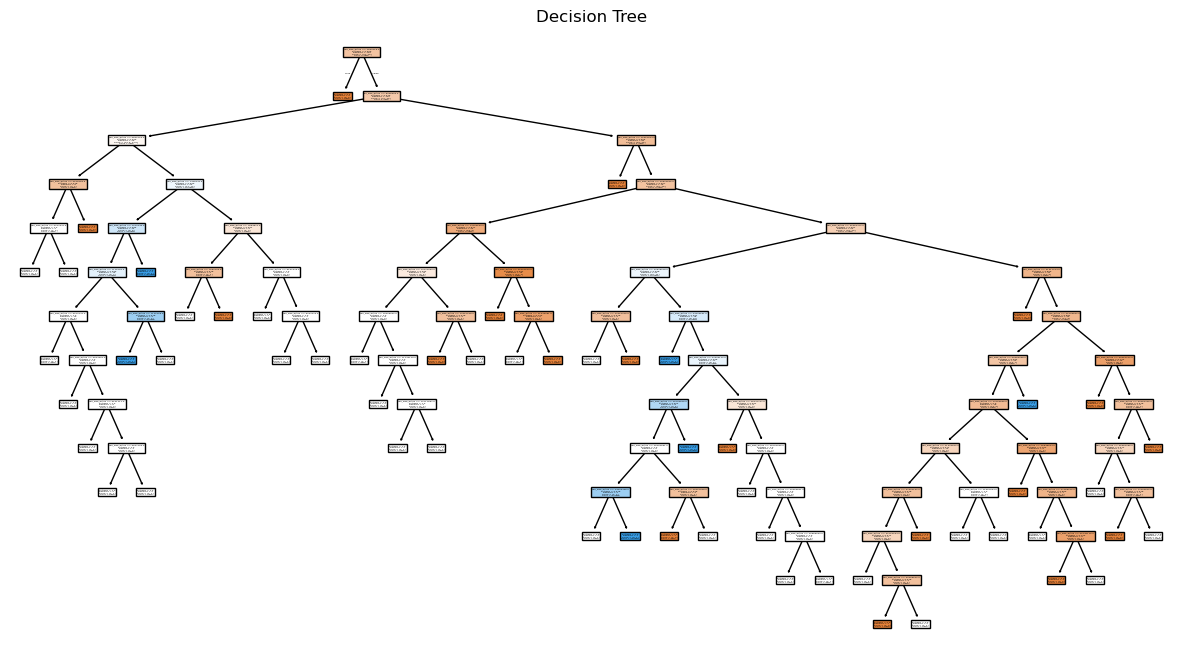

In [ ]:
#A6
plt.figure(figsize=(15,8))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Safe","Unsafe"],
    filled=True
)

plt.title("Decision Tree")

plt.show()


In [ ]:
#A7
features = X.columns[:2]

X2 = df[list(features)]
y2 = df["label"]

dt2 = DecisionTreeClassifier()

dt2.fit(X2, y2)


DecisionTreeClassifier()

c:\Users\yuvaa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


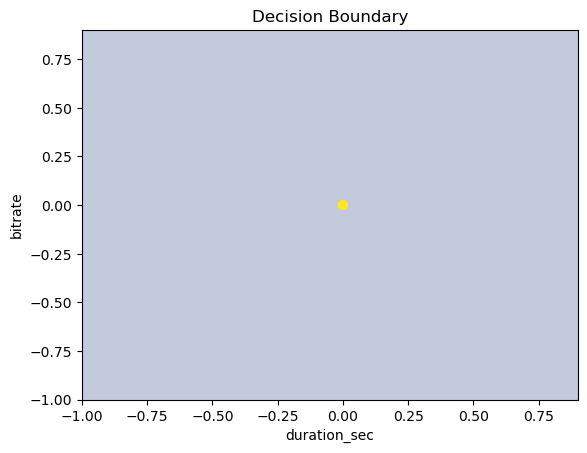

In [ ]:
x_min, x_max = X2.iloc[:,0].min()-1, X2.iloc[:,0].max()+1
y_min, y_max = X2.iloc[:,1].min()-1, X2.iloc[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = dt2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X2.iloc[:,0], X2.iloc[:,1], c=pd.factorize(y2)[0])

plt.xlabel(features[0])
plt.ylabel(features[1])

plt.title("Decision Boundary")

plt.show()